# Training a convolutional neural network on the CIFAR-10 dataset using PyTorch.

## Preparing my data
I have downloaded the CIFAR-10 dataset from the University of Toronto's website. I will be using a standard predefined transform to turn the images into tensors, normalizing pixel values to have a mean of 0 and a standard deviation of 1.

In [1]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.4914, 0.4822, 0.4465), std = (0.2470, 0.2435, 0.2616)) # I used the standard, pre-calculated mean and standard deviation for CIFAR-10
])

I will split the data into three sets: training, validation and testing. I will also apply the transform to the three sets.

In [2]:
from torch.utils.data import random_split
from torchvision import datasets

training_data, validation_data = random_split(datasets.CIFAR10(root = "./data", train = True, download = False, transform = transform), [45000, 5000])
testing_data = datasets.CIFAR10(root = "./data", train = False, download = False, transform = transform)

print(f"Training data: {len(training_data)}")
print(f"Validation data: {len(validation_data)}")
print(f"Testing data: {len(testing_data)}")
print(f"Classes: {testing_data.classes}")

Training data: 45000
Validation data: 5000
Testing data: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


I will now create the DataLoader object that will feed the data into my model when training. I chose batch_size = 64 because it has seemed like the standard when I have been researching.

In [3]:
from torch.utils.data import DataLoader

training_loader = DataLoader(training_data, batch_size = 64, shuffle = True)
validation_loader = DataLoader(validation_data, batch_size = 64, shuffle = False)
testing_loader = DataLoader(testing_data, batch_size = 64, shuffle = False)

## Defining my model
I chose 3 convolutional layers because it seemed like a reasonable depth for images this small. My intuition: the first layer picks up on simple things like edges and lines, the second combines those into shapes, and the third combines shapes into more complex patterns.

I doubled the channels at each layer (16 → 32 → 64) based on the same intuition. The first layer doesn't need many features to detect lines, but as you move deeper there are more possible combinations of shapes to represent, so more channels make sense. I also saw this doubling pattern used commonly while researching CNN architectures, which reinforced the choice.

In [ ]:
from torch import nn

class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()

        # Pooling, activation and flattening
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.relu = nn.ReLU()
        self.flatten = nn.Flatten()

        # Layer 1
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling

        # Layer 2
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling

        # Layer 3
        self.conv3 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling

        # Dense layers
        # Flattening
        self.fc1 = nn.Linear(in_features = 4 * 4 * 64, out_features = 64)
        # ReLU
        self.fc2 = nn.Linear(in_features = 64, out_features = 10)
    
    def forward(self, x):
        # Layer 1
        x = self.pool(self.relu(self.conv1(x)))

        # Layer 2
        x = self.pool(self.relu(self.conv2(x)))

        # Layer 3
        x = self.pool(self.relu(self.conv3(x)))

        # Dense layers
        return self.fc2(self.relu(self.fc1(self.flatten(x))))

## Defining my loss function and optimizer
I chose Adam as my optimizer mainly because it was simple to set up and get working. For the learning rate, I used 0.001, which I found to be the commonly recommended default for Adam.

In [ ]:
from torch import optim

model = ModelV1()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = model.parameters(), lr = 0.001)

## Defining my training loop

In [ ]:
from torch import no_grad, max

# History for plotting results
training_losses = []
training_accuracies = []
validation_losses = []
validation_accuracies = []

epochs = 10 # Small number of epochs just to check if the model overfits.

for epoch in range(epochs):
    # Put the model in training mode and reset running loss
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in training_loader:
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = criterion(predictions, labels)

        # Accuracy
        _, prediction = max(predictions, dim = 1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)

        # Backpropagation
        loss.backward()

        # Adjust weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    # Validation
    model.eval()
    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0

    with no_grad():
        for images, labels in validation_loader:
            predictions = model(images)

            loss = criterion(predictions, labels)

            validation_loss += loss.item() * images.size(0)

            _, prediction = max(predictions.data, dim = 1)
            validation_correct += (prediction == labels).sum().item()
            validation_total += labels.size(0)

    # Calculating loss and accuracy for the epoch
    epoch_loss = running_loss / total
    epoch_validation_loss = validation_loss / validation_total
    epoch_accuracy = correct / total
    epoch_validation_accuracy = validation_correct / validation_total

    training_losses.append(epoch_loss)
    training_accuracies.append(epoch_accuracy)
    validation_losses.append(epoch_validation_loss)
    validation_accuracies.append(epoch_validation_accuracy)

    print(f"Epoch [{epoch + 1} / {epochs}]\n"
        f"Training loss: {epoch_loss:.4f}, Training accuracy: {epoch_accuracy * 100:.2f}%\n"
        f"Validation loss: {epoch_validation_loss:.4f}, Validation accuracy: {epoch_validation_accuracy * 100:.2f}%")


Epoch [1 / 10]
Training loss: 1.5259, Training accuracy: 44.43%
Validation loss: 1.2891, Validation accuracy: 53.28%
Epoch [2 / 10]
Training loss: 1.1483, Training accuracy: 59.05%
Validation loss: 1.0542, Validation accuracy: 63.06%
Epoch [3 / 10]
Training loss: 0.9789, Training accuracy: 65.77%
Validation loss: 1.0675, Validation accuracy: 62.64%
Epoch [4 / 10]
Training loss: 0.8706, Training accuracy: 69.65%
Validation loss: 0.9182, Validation accuracy: 67.46%
Epoch [5 / 10]
Training loss: 0.7905, Training accuracy: 72.30%
Validation loss: 0.8527, Validation accuracy: 70.80%
Epoch [6 / 10]
Training loss: 0.7255, Training accuracy: 74.78%
Validation loss: 0.8287, Validation accuracy: 71.88%
Epoch [7 / 10]
Training loss: 0.6736, Training accuracy: 76.50%
Validation loss: 0.8539, Validation accuracy: 71.26%
Epoch [8 / 10]
Training loss: 0.6216, Training accuracy: 78.33%
Validation loss: 0.8444, Validation accuracy: 71.70%
Epoch [9 / 10]
Training loss: 0.5861, Training accuracy: 79.32%


## Plotting

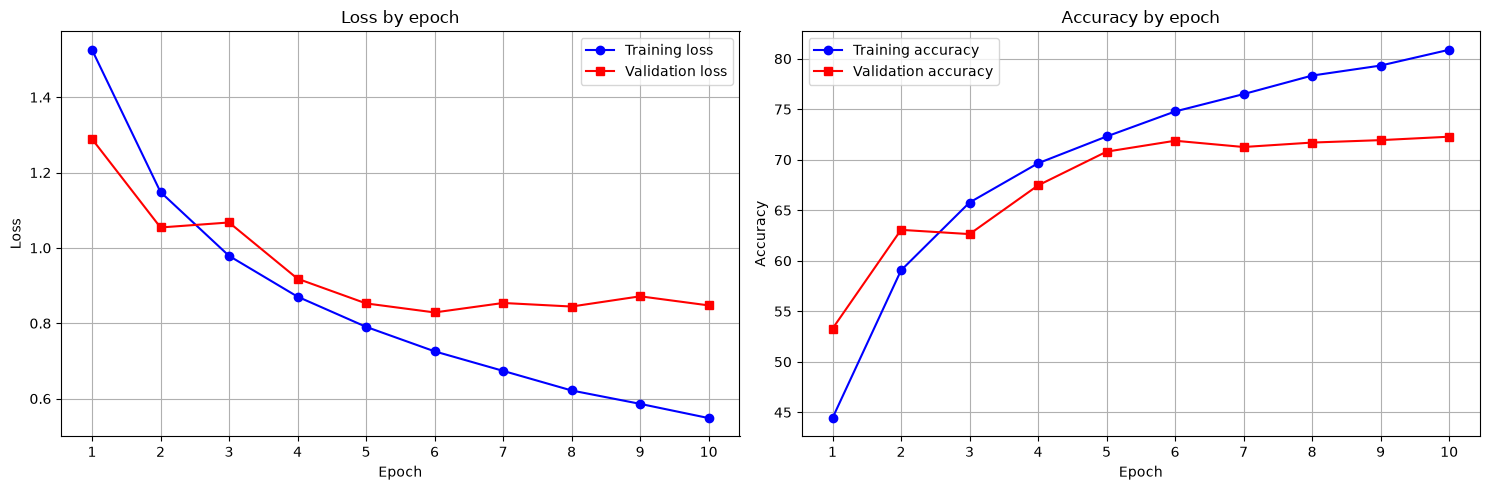

In [7]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1 - Loss
ax1.plot(training_losses, label = 'Training loss', color = 'blue', marker = 'o')
ax1.plot(validation_losses, label = 'Validation loss', color = 'red', marker = 's')
ax1.set_title('Loss by epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(range(epochs))
ax1.set_xticklabels(range(1, epochs + 1))
ax1.legend()
ax1.grid(True)

# Graph 2 - Accuracy
ax2.plot([acc * 100 for acc in training_accuracies], label = 'Training accuracy', color = 'blue', marker='o')
ax2.plot([acc * 100 for acc in validation_accuracies], label = 'Validation accuracy', color='red', marker='s')
ax2.set_title('Accuracy by epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(range(epochs))
ax2.set_xticklabels(range(1, epochs + 1))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## Thoughts about the model's performance
The model seems to start overfitting around epoch 3. It seems like it stops learning useful stuff after epoch 6.

## Improving the model
I will start by making two changes:
1. Data augmentation
    I will be applying random flipping and cropping transformations to the images before giving them to my model for training. This makes it less likely that the model will "remember" specific images.
2. Adding dropout
    Dropout layers randomly turn off a percentage of neurons in order to force the network to not rely too much on a single neuron. I will add weak dropout layers between convolutional layers and a stronger one in the dense layers.

In [29]:
# Data augmentation
from copy import deepcopy

new_transform = transforms.Compose([
    transforms.RandomCrop(size = 32, padding = 2),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean = (0.4914, 0.4822, 0.4465), std = (0.2470, 0.2435, 0.2616)) # I used the standard, pre-calculated mean and standard deviation for CIFAR-10
])

new_training_data = deepcopy(training_data)
new_training_data.dataset.transform = new_transform

new_training_loader = DataLoader(new_training_data, batch_size = 64, shuffle = True)

In [ ]:
# Redefining the model with dropout
class ModelV2(nn.Module):
    def __init__(self):
        super().__init__()

        # Activation, pooling, dropout and flattening
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.dropout_light = nn.Dropout(p = 0.25)
        self.dropout_heavy = nn.Dropout(p = 0.5)
        self.flatten = nn.Flatten()

        # Layer 1
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling
        # Light dropout

        # Layer 2
        self.conv2 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling
        # Light dropout

        # Layer 3
        self.conv3 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
        # ReLU
        # Pooling
        # Light dropout

        # Dense layers
        # Flattening
        self.fc1 = nn.Linear(in_features = 4 * 4 * 64, out_features = 64)
        # ReLU
        # Heavy dropout
        self.fc2 = nn.Linear(in_features = 64, out_features = 10)
    
    def forward(self, x):
        # Layer 1
        x = self.dropout_light(self.pool(self.relu(self.conv1(x))))

        # Layer 2
        x = self.dropout_light(self.pool(self.relu(self.conv2(x))))

        # Layer 3
        x = self.dropout_light(self.pool(self.relu(self.conv3(x))))

        # Dense layers
        return self.fc2(self.dropout_heavy(self.relu(self.fc1(self.flatten(x)))))

In [ ]:
model = ModelV2()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(params = model.parameters(), lr = 0.001)

In [ ]:
# History for plotting results
training_losses = []
training_accuracies = []
validation_losses = []
validation_accuracies = []

epochs = 50 # Runnig for 50 epochs now since regularization slows convergence

for epoch in range(epochs):
    # Put the model in training mode and reset running loss
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in new_training_loader:
        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        predictions = model(images)

        # Calculate loss
        loss = criterion(predictions, labels)

        # Accuracy
        _, prediction = max(predictions, dim = 1)
        correct += (prediction == labels).sum().item()
        total += labels.size(0)

        # Backpropagation
        loss.backward()

        # Adjust weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    # Validation
    model.eval()
    validation_loss = 0.0
    validation_correct = 0
    validation_total = 0

    with no_grad():
        for images, labels in validation_loader:
            predictions = model(images)

            loss = criterion(predictions, labels)

            validation_loss += loss.item() * images.size(0)

            _, prediction = max(predictions.data, dim = 1)
            validation_correct += (prediction == labels).sum().item()
            validation_total += labels.size(0)

    # Calculating loss and accuracy for the epoch
    epoch_loss = running_loss / total
    epoch_validation_loss = validation_loss / validation_total
    epoch_accuracy = correct / total
    epoch_validation_accuracy = validation_correct / validation_total

    training_losses.append(epoch_loss)
    training_accuracies.append(epoch_accuracy)
    validation_losses.append(epoch_validation_loss)
    validation_accuracies.append(epoch_validation_accuracy)

    print(f"Epoch [{epoch + 1} / {epochs}]\n"
        f"Training loss: {epoch_loss:.4f}, Training accuracy: {epoch_accuracy * 100:.2f}%\n"
        f"Validation loss: {epoch_validation_loss:.4f}, Validation accuracy: {epoch_validation_accuracy * 100:.2f}%")


Epoch [1 / 50]
Training loss: 1.8240, Training accuracy: 32.77%
Validation loss: 1.4733, Validation accuracy: 47.72%
Epoch [2 / 50]
Training loss: 1.5642, Training accuracy: 42.93%
Validation loss: 1.3168, Validation accuracy: 52.26%
Epoch [3 / 50]
Training loss: 1.4724, Training accuracy: 46.72%
Validation loss: 1.2348, Validation accuracy: 55.48%
Epoch [4 / 50]
Training loss: 1.4018, Training accuracy: 49.50%
Validation loss: 1.1404, Validation accuracy: 59.32%
Epoch [5 / 50]
Training loss: 1.3458, Training accuracy: 51.52%
Validation loss: 1.1064, Validation accuracy: 60.98%
Epoch [6 / 50]
Training loss: 1.3124, Training accuracy: 52.75%
Validation loss: 1.0788, Validation accuracy: 61.98%
Epoch [7 / 50]
Training loss: 1.2783, Training accuracy: 54.30%
Validation loss: 1.0562, Validation accuracy: 61.88%
Epoch [8 / 50]
Training loss: 1.2558, Training accuracy: 55.49%
Validation loss: 1.0170, Validation accuracy: 63.60%
Epoch [9 / 50]
Training loss: 1.2282, Training accuracy: 56.49%


Plotting again.

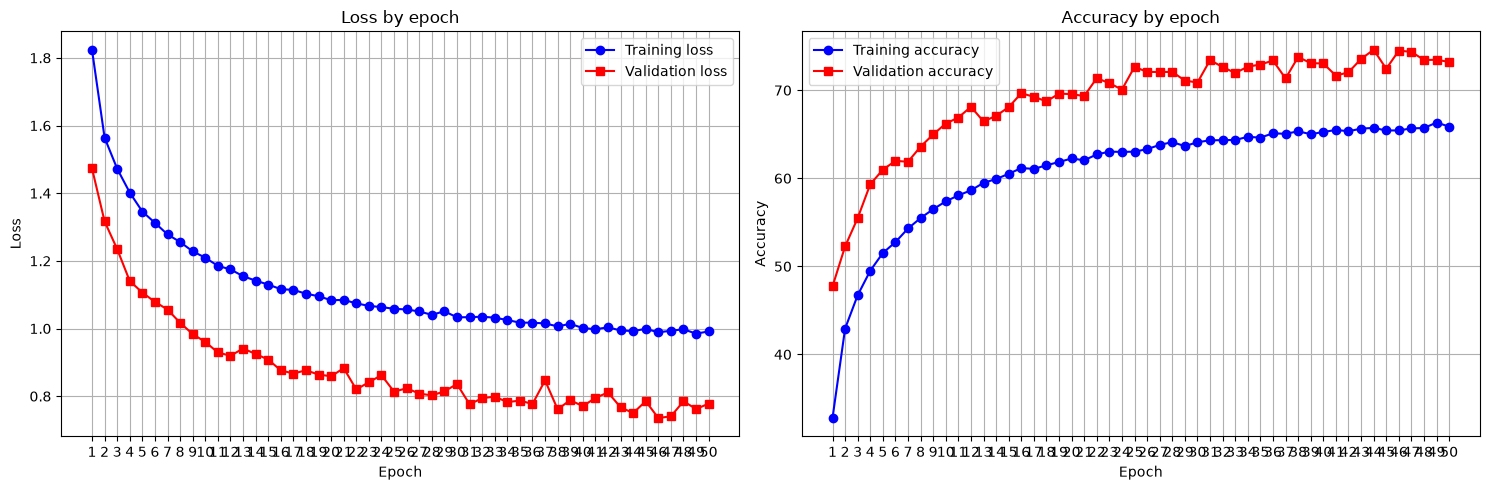

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1 - Loss
ax1.plot(training_losses, label = 'Training loss', color = 'blue', marker = 'o')
ax1.plot(validation_losses, label = 'Validation loss', color = 'red', marker = 's')
ax1.set_title('Loss by epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_xticks(range(epochs))
ax1.set_xticklabels(range(1, epochs + 1))
ax1.legend()
ax1.grid(True)

# Graph 2 - Accuracy
ax2.plot([acc * 100 for acc in training_accuracies], label = 'Training accuracy', color = 'blue', marker='o')
ax2.plot([acc * 100 for acc in validation_accuracies], label = 'Validation accuracy', color='red', marker='s')
ax2.set_title('Accuracy by epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_xticks(range(epochs))
ax2.set_xticklabels(range(1, epochs + 1))
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## Thoughts about the model's performance
The model is no longer overfitting. It seems like it is learning pretty well, but plateaus.

In [35]:
from torch import save

save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'epoch': epoch,
    'val_loss': epoch_validation_loss,
}, "weights.pth")